<a href="https://colab.research.google.com/github/ridham123456/docs/blob/main/Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import pandas as pd
import numpy as np
df1=house_prices=pd.read_csv("House_Price.csv")
df2=kc_data=pd.read_csv("KC_BL_DATASET.csv")
print(f"house Price Shape={house_prices.shape}")
print(f"kc data Shape={kc_data.shape}")
house_prices.columns



house Price Shape=(506, 19)
kc data Shape=(437, 22)


Index(['price', 'crime_rate', 'resid_area', 'air_qual', 'room_num', 'age',
       'dist1', 'dist2', 'dist3', 'dist4', 'teachers', 'poor_prop', 'airport',
       'n_hos_beds', 'n_hot_rooms', 'waterbody', 'rainfall', 'bus_ter',
       'parks'],
      dtype='object')

In [63]:
kc_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_above,sqft_basement,yr_built,...,Genre_2,Genre_3,imdb_rating,length,rank_in_year,rating,studio,title,worldwide_gross,year
0,5652600427,20150224T000000,420000,4,2.00,1700,6375,850,850,1950,...,Adventure,Drama,7.4,135,1,PG-13,Walt Disney Pictures,Black Panther,700059566,2018
1,7888000390,20140627T000000,140000,3,1.00,1060,7473,1060,0,1959,...,Adventure,Sci-Fi,8.5,156,2,PG-13,Walt Disney Pictures,Avengers: Infinity War,678815482,2018
2,5318101695,20150409T000000,940000,4,1.50,2430,3600,2430,0,1980,...,Action,Adventure,7.8,118,3,PG,Pixar,Incredibles 2,608581744,2018
3,4039000050,20140714T000000,516130,3,1.75,1510,8250,1510,0,1962,...,Adventure,Drama,6.2,129,4,PG-13,Universal Pictures,Jurassic World: Fallen Kingdom,416769345,2018
4,7853230590,20141029T000000,435000,4,2.50,2190,6578,2190,0,2004,...,Comedy,NaN,7.8,119,5,R,20th Century Fox,Deadpool 2,318491426,2018


In [64]:
house_prices.info()
kc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        506 non-null    float64
 1   crime_rate   506 non-null    float64
 2   resid_area   506 non-null    float64
 3   air_qual     506 non-null    float64
 4   room_num     506 non-null    float64
 5   age          506 non-null    float64
 6   dist1        506 non-null    float64
 7   dist2        506 non-null    float64
 8   dist3        506 non-null    float64
 9   dist4        506 non-null    float64
 10  teachers     506 non-null    float64
 11  poor_prop    506 non-null    float64
 12  airport      506 non-null    object 
 13  n_hos_beds   498 non-null    float64
 14  n_hot_rooms  506 non-null    float64
 15  waterbody    351 non-null    object 
 16  rainfall     506 non-null    int64  
 17  bus_ter      506 non-null    object 
 18  parks        506 non-null    float64
dtypes: float

In [65]:
print(house_prices.isnull().sum())
print(kc_data.isnull().sum())


price            0
crime_rate       0
resid_area       0
air_qual         0
room_num         0
age              0
dist1            0
dist2            0
dist3            0
dist4            0
teachers         0
poor_prop        0
airport          0
n_hos_beds       8
n_hot_rooms      0
waterbody      155
rainfall         0
bus_ter          0
parks            0
dtype: int64
id                   0
date                 0
price                0
bedrooms             0
bathrooms            0
sqft_living          0
sqft_lot             0
sqft_above           0
sqft_basement        0
yr_built             0
yr_renovated         0
Main_Genre           0
Genre_2             29
Genre_3            141
imdb_rating          0
length               0
rank_in_year         0
rating               0
studio               0
title                0
worldwide_gross      0
year                 0
dtype: int64


In [66]:
house_prices.fillna(house_prices.median(numeric_only=True), inplace=True)
kc_data.fillna(kc_data.median(numeric_only=True),inplace=True)
num_cols=df1.select_dtypes(include=['int64','float64']).columns
df1[num_cols]=df1[num_cols].fillna(
    df1[num_cols].median()
)
cat_cols=df1.select_dtypes(include='object').columns
df1[cat_cols]=df1[cat_cols].fillna('Unknown')

In [67]:
print(house_prices.duplicated().sum())
print(kc_data.duplicated().sum())

0
0


In [68]:
kc_data["date"]=pd.to_datetime(kc_data["date"])
kc_data["date"].head()

,date
0,2015-02-24
1,2014-06-27
2,2015-04-09
3,2014-07-14
4,2014-10-29


In [69]:
house_prices.columns=[c.strip().lower().replace(" ","_") for c in house_prices.columns]
kc_data.columns=[c.strip().lower().replace(" ","_") for c in kc_data.columns]

In [70]:
house_prices.info()
kc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        506 non-null    float64
 1   crime_rate   506 non-null    float64
 2   resid_area   506 non-null    float64
 3   air_qual     506 non-null    float64
 4   room_num     506 non-null    float64
 5   age          506 non-null    float64
 6   dist1        506 non-null    float64
 7   dist2        506 non-null    float64
 8   dist3        506 non-null    float64
 9   dist4        506 non-null    float64
 10  teachers     506 non-null    float64
 11  poor_prop    506 non-null    float64
 12  airport      506 non-null    object 
 13  n_hos_beds   506 non-null    float64
 14  n_hot_rooms  506 non-null    float64
 15  waterbody    506 non-null    object 
 16  rainfall     506 non-null    int64  
 17  bus_ter      506 non-null    object 
 18  parks        506 non-null    float64
dtypes: float

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

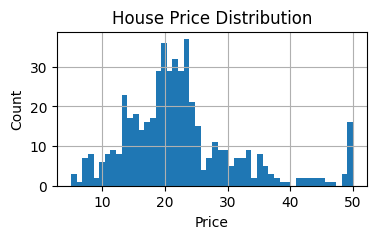

In [72]:
plt.figure(figsize=(4,2))
house_prices['price'].hist(bins=50)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

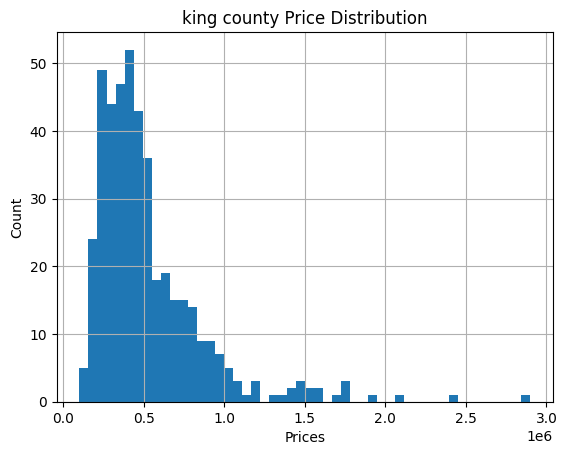

In [73]:
kc_data['price'].hist(bins=50)
plt.title("king county Price Distribution")
plt.xlabel("Prices")
plt.ylabel("Count")
plt.show()


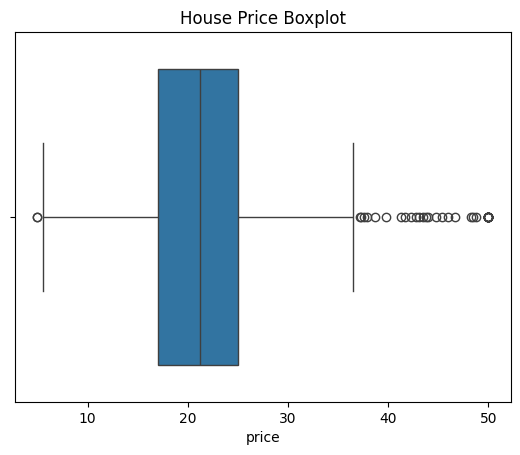

In [74]:
sns.boxplot(x=house_prices['price'])
plt.title("House Price Boxplot")
plt.show()

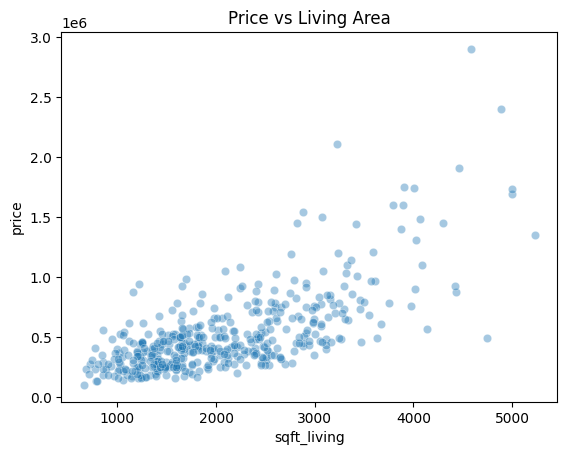

In [75]:
sns.scatterplot(
    x='sqft_living',
    y='price',
    data=kc_data,
    alpha=0.4
)
plt.title("Price vs Living Area")
plt.show()

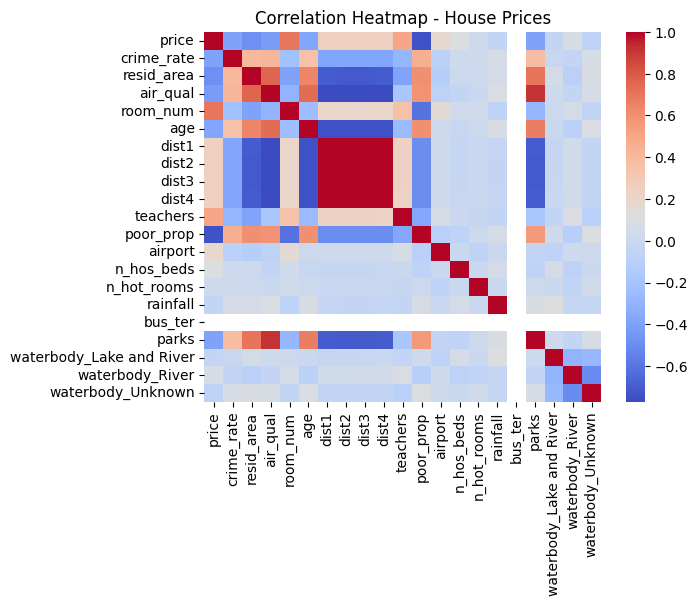

In [76]:
df1['airport']=df1['airport'].map({
    'YES':1,
    'NO':0
})
df1=pd.get_dummies(
    df1,
    columns=["waterbody"],
    drop_first=True
)
df1['bus_ter']=df1['bus_ter'].map({
    'YES':1,
    'NO':0
})
df1[['bus_ter','airport']]=df1[['bus_ter','airport']].fillna(0)
sns.heatmap(
    df1.corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap - House Prices")
plt.show()

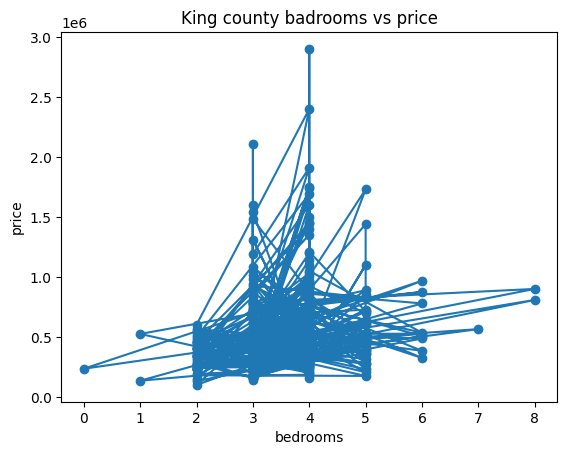

In [77]:
from matplotlib import markers
plt.plot(
    kc_data['bedrooms'],
    kc_data['price'],
    marker='o'
)
plt.title("King county badrooms vs price")
plt.xlabel("bedrooms")
plt.ylabel("price")
plt.show()



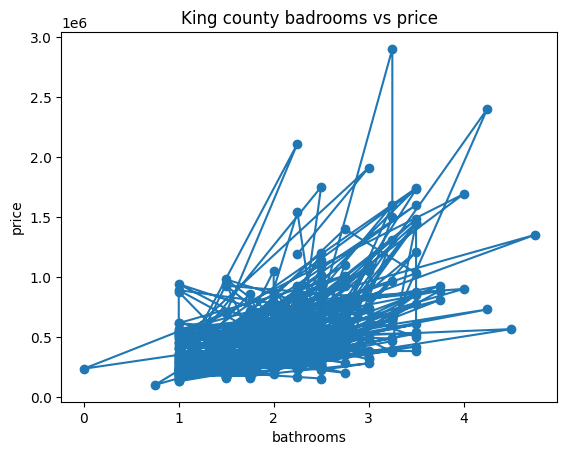

In [78]:
from matplotlib import markers
plt.plot(
    kc_data['bathrooms'],
    kc_data['price'],
    marker='o'
)
plt.title("King county badrooms vs price")
plt.xlabel("bathrooms")
plt.ylabel("price")
plt.show()



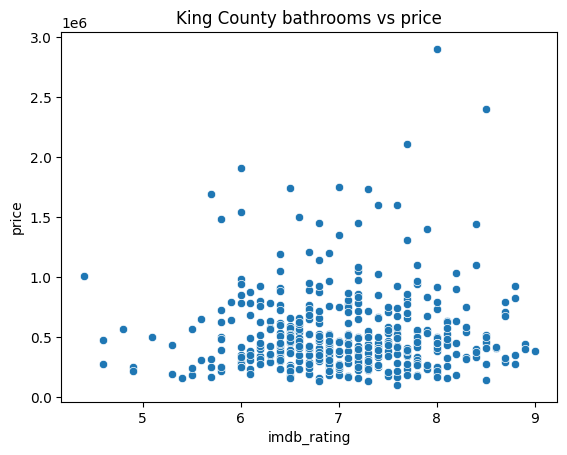

In [79]:
sns.scatterplot(
    x="imdb_rating",
    y="price",
    data=kc_data
)
plt.title("King County bathrooms vs price")
plt.xlabel("imdb_rating")
plt.ylabel("price")
plt.show()

Text(0.5, 1.0, 'Price Distribution by Main genre')

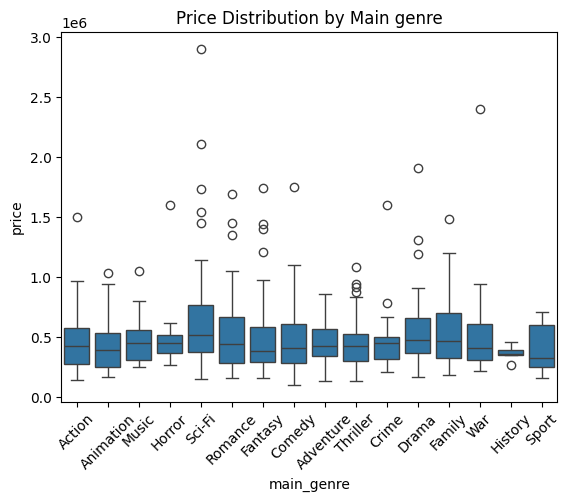

In [80]:
sns.boxplot(
    x='main_genre',
    y='price',
    data=kc_data
)
plt.xticks(rotation=45)
plt.title("Price Distribution by Main genre")

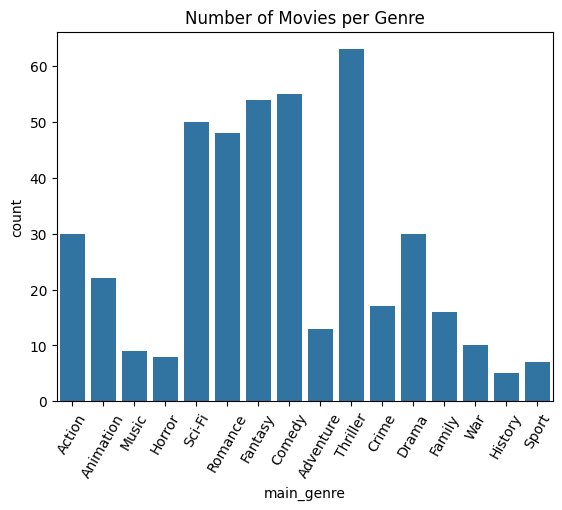

In [81]:
sns.countplot(
    x='main_genre',
    data=kc_data
)
plt.xticks(rotation=60)
plt.title("Number of Movies per Genre")
plt.show()

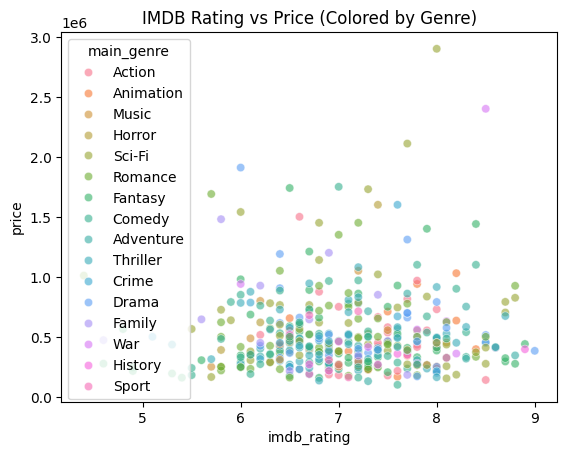

In [82]:
sns.scatterplot(
    x='imdb_rating',
    y='price',
    hue='main_genre',
    data=kc_data,
    alpha=0.6
)
plt.title("IMDB Rating vs Price (Colored by Genre)")
plt.show()

In [83]:
df1.head()

,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,...,poor_prop,airport,n_hos_beds,n_hot_rooms,rainfall,bus_ter,parks,waterbody_Lake and River,waterbody_River,waterbody_Unknown
0,24.0,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,...,4.98,1,5.480,11.1920,23,1,0.049347,False,True,False
1,21.6,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,...,9.14,0,7.332,12.1728,42,1,0.046146,False,False,False
2,34.7,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,...,4.03,0,7.394,101.1200,38,1,0.045764,False,False,True
3,33.4,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,...,2.94,1,9.268,11.2672,45,1,0.047151,False,False,False
4,36.2,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,...,5.33,0,8.824,11.2896,55,1,0.039474,False,False,False


In [84]:
df1['waterbody_Lake and River']=df1['waterbody_Lake and River'].map({
    'True':1,
    'False':0
})
df1['waterbody_River']=df1['waterbody_River'].map({
    'True':1,
    'False' :0
})
dummy_cols = [col for col in df1.columns if col.startswith('waterbody_')]
df1[dummy_cols] = df1[dummy_cols].fillna(0)

df1.isnull().sum().sort_values(ascending=False)

x=df1.drop("price", axis=1)
y=df1["price"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report,confusion_matrix
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [85]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred=lr.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(f"MAE-:{mae}")
print(f"RMSE-:{rmse}")
print(f"R2-:{r2}")

MAE-:3.330429985171609
RMSE-:5.065171580744528
R2-:0.6520954601379941


In [86]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
mae_rf=mean_absolute_error(y_test,y_pred_rf)
mse_rf=mean_squared_error(y_test,y_pred_rf)
rmse_rf=np.sqrt(mse_rf)
r2_rf=r2_score(y_test,y_pred_rf)
print(f"RF MAE-:{mae_rf}")
print(f"RF RMSE-:{rmse_rf}")
print(f"RF R2-:{r2_rf}")

RF MAE-:2.0616732026143776
RF RMSE-:3.1667911076340314
RF R2-:0.8640088624894544
